# Logistic — Main Report Analysis

This notebook is the branch-specific main-report analysis for **Logistic**.

It keeps the focus on the three supervisor-prioritized indicators:

- **CI Overlap (CIO)**
- **Bias Ratio (SD / OD)**
- **CI Width Ratio (SD / OD)**

The visual workflow is:

1. **PCA + t-SNE** to identify broad patterns.
2. **Univariate descriptive analysis** for each factor separately.
3. **Cross-analysis by method** using the combined synthesis arm against the remaining factors.

In [1]:
# ── Imports & Config ─────────────────────────────────────────────────────────
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

warnings.filterwarnings("ignore", category=FutureWarning)

TARGET_REG   = "logistic"
TARGET_LABEL = "Logistic"
PARQUET_NAME = "aggregated_logistic_metrics.parquet"

config_path = os.path.join("..", "config", "config.json")
with open(config_path) as f:
    config = json.load(f)

N_VALS       = sorted(config["simulation"]["N"])
P_VALS       = sorted(config["simulation"]["p"])
VAR_TYPES    = sorted(config["simulation"]["var_type"])
RHO_VALS     = sorted([float(r) for r in config["parameters"]["rho"]])
SIGMA2_VALS  = sorted([float(s) for s in config["parameters"]["sigma_2"]])
BETA_TRUE    = np.array([float(b) for b in config["parameters"]["beta"]])
CONT_METHODS = [m.upper() for m in config["synthesis"]["continuous_methods"]]
BIN_METHODS  = [m.upper() for m in config["synthesis"]["binary_methods"]]

ARMS = {
    ("linear",   "continuous"): [(m, m) for m in CONT_METHODS],
    ("linear",   "binary"):     [(xm, ym) for xm in BIN_METHODS for ym in CONT_METHODS],
    ("logistic", "continuous"): [(xm, ym) for xm in CONT_METHODS for ym in BIN_METHODS],
    ("logistic", "binary"):     [(m, m) for m in BIN_METHODS],
}

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman"],
    "mathtext.fontset": "cm",
})

result_dir = os.path.join("..", "results")
fig_dir = os.path.join(result_dir, f"{TARGET_REG}_report_figures")
os.makedirs(fig_dir, exist_ok=True)

print(f"Target branch: {TARGET_LABEL}")
print(f"N: {N_VALS}")
print(f"p: {P_VALS}")
print(f"rho: {RHO_VALS}")
print(f"Error variance (sigma²): {SIGMA2_VALS}")

Target branch: Logistic
N: [100, 500, 1000]
p: [2, 5, 10]
rho: [0.0, 0.3, 0.6]
Error variance (sigma²): [0.5, 1.0, 2.0]


In [2]:
# ── Load branch-specific parquet ─────────────────────────────────────────────
df = pd.read_parquet(os.path.join(result_dir, PARQUET_NAME)).copy()
df["rho"] = df["rho"].round(6)
df["sigma_2"] = df["sigma_2"].round(6)
df["arm"] = "X" + df["x_method"] + "_Y" + df["y_method"]

expected_arms = sorted({f"X{xm}_Y{ym}" for vt in VAR_TYPES for xm, ym in ARMS[(TARGET_REG, vt)]})

print(f"Loaded {len(df):,} rows x {len(df.columns)} cols")
print(f"Observed arms: {sorted(df['arm'].unique())}")
print(f"Expected arms: {expected_arms}")

Loaded 486,000 rows x 85 cols
Observed arms: ['XCART_YCART', 'XCART_YLOGREG', 'XLOGREG_YLOGREG', 'XNORM_YCART', 'XNORM_YLOGREG']
Expected arms: ['XCART_YCART', 'XCART_YLOGREG', 'XLOGREG_YLOGREG', 'XNORM_YCART', 'XNORM_YLOGREG']


In [3]:
# ── Derive main indicators ───────────────────────────────────────────────────
_num_key = lambda c: int(c.rsplit("_", 1)[-1])

beta_od_cols = sorted([c for c in df.columns if c.startswith("beta_od_")], key=_num_key)
beta_sd_cols = sorted([c for c in df.columns if c.startswith("beta_sd_")], key=_num_key)
se_od_cols   = sorted([c for c in df.columns if c.startswith("se_od_")], key=_num_key)
se_sd_cols   = sorted([c for c in df.columns if c.startswith("se_sd_")], key=_num_key)

beta_od_slope = [c for c in beta_od_cols if c != "beta_od_0"]
beta_sd_slope = [c for c in beta_sd_cols if c != "beta_sd_0"]
se_od_slope   = [c for c in se_od_cols   if c != "se_od_0"]
se_sd_slope   = [c for c in se_sd_cols   if c != "se_sd_0"]

bo = df[beta_od_slope].values
bs = df[beta_sd_slope].values
so = df[se_od_slope].values
ss = df[se_sd_slope].values

true_slopes = BETA_TRUE[1:1 + len(beta_od_slope)]

L_od = bo - 1.96 * so
U_od = bo + 1.96 * so
L_sd = bs - 1.96 * ss
U_sd = bs + 1.96 * ss

U_inter = np.minimum(U_od, U_sd)
L_inter = np.maximum(L_od, L_sd)
inter_len = np.maximum(0, U_inter - L_inter)
W_od = U_od - L_od
W_sd = U_sd - L_sd

valid_ci = (
    ~np.isnan(bo) & ~np.isnan(bs) & ~np.isnan(so) & ~np.isnan(ss) &
    (so > 0) & (ss > 0) & (W_od > 0) & (W_sd > 0)
)

with np.errstate(divide="ignore", invalid="ignore"):
    cio = np.where(valid_ci, 0.5 * (inter_len / W_od + inter_len / W_sd) * 100, np.nan)
    width_ratio = np.where(valid_ci, W_sd / W_od, np.nan)

df["ci_overlap_pct"] = np.nanmean(cio, axis=1)
df["ci_width_ratio"] = np.nanmean(width_ratio, axis=1)

od_abs_bias = np.abs(bo - true_slopes)
sd_abs_bias = np.abs(bs - true_slopes)
df["mean_abs_bias_od"] = np.nanmean(od_abs_bias, axis=1)
df["mean_abs_bias_sd"] = np.nanmean(sd_abs_bias, axis=1)

with np.errstate(divide="ignore", invalid="ignore"):
    df["bias_ratio"] = df["mean_abs_bias_sd"] / df["mean_abs_bias_od"]
df.loc[~np.isfinite(df["bias_ratio"]), "bias_ratio"] = np.nan
df["log10_bias_ratio"] = np.where(df["bias_ratio"] > 0, np.log10(df["bias_ratio"]), np.nan)
df["log10_ci_width_ratio"] = np.where(df["ci_width_ratio"] > 0, np.log10(df["ci_width_ratio"]), np.nan)

METRICS = [
    ("ci_overlap_pct", "CI Overlap (%)", "cio"),
    ("bias_ratio", "Bias Ratio (SD / OD)", "bias_ratio"),
    ("ci_width_ratio", "CI Width Ratio (SD / OD)", "ci_width_ratio"),
]

print(df[["ci_overlap_pct", "bias_ratio", "ci_width_ratio"]].describe().T[["mean", "std", "min", "max"]])

                     mean        std       min         max
ci_overlap_pct  62.453768  20.587336  0.000000   99.653962
bias_ratio       2.219464   2.619904  0.003910  425.219132
ci_width_ratio   1.028014   0.221140  0.086794   13.847860


In [4]:
# ── Plot helpers & palettes ──────────────────────────────────────────────────
VAR_TYPE_PALETTE = {"binary": "#2A9D8F", "continuous": "#E76F51"}
ARM_ORDER = sorted(df["arm"].dropna().unique())
ARM_PALETTE = dict(zip(ARM_ORDER, sns.color_palette("Set2", n_colors=len(ARM_ORDER))))

FACTOR_SPECS = [
    ("var_type", "Variable Type", VAR_TYPES),
    ("N", "Sample Size (N)", N_VALS),
    ("p", "Number of Predictors (p)", P_VALS),
    ("rho", "Correlation (rho)", RHO_VALS),
    ("sigma_2", "Error Variance (sigma²)", SIGMA2_VALS),
    ("arm", "Synthesis Arm", ARM_ORDER),
]

CROSS_FACTOR_SPECS = [
    ("var_type", "Variable Type", VAR_TYPES),
    ("N", "Sample Size (N)", N_VALS),
    ("p", "Number of Predictors (p)", P_VALS),
    ("rho", "Correlation (rho)", RHO_VALS),
    ("sigma_2", "Error Variance (sigma²)", SIGMA2_VALS),
]

def _as_cat(values):
    return values.astype(str) if values.dtype.kind in "if" else values.astype(str)

def _palette_for(col, order):
    if col == "var_type":
        return {str(k): VAR_TYPE_PALETTE[k] for k in order}
    if col == "arm":
        return {str(k): ARM_PALETTE[k] for k in order}
    if col == "N":
        return dict(zip([str(v) for v in order], sns.color_palette("crest", len(order))))
    if col == "p":
        return dict(zip([str(v) for v in order], sns.color_palette("flare", len(order))))
    if col == "rho":
        return dict(zip([str(v) for v in order], sns.color_palette("viridis", len(order))))
    if col == "sigma_2":
        return dict(zip([str(v) for v in order], sns.color_palette("magma", len(order))))
    return None

def _add_reference_line(ax, metric_col):
    if metric_col in {"bias_ratio", "ci_width_ratio"}:
        ax.axhline(1.0, color="black", lw=1.3, ls="--", alpha=0.7, zorder=2)

def _apply_metric_axis(ax, metric_col):
    if metric_col in {"bias_ratio", "ci_width_ratio"}:
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2g}" if y > 0 else ""))

def make_univariate_distribution_grid(data, metric_col, metric_label, file_stub):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), squeeze=False)
    axes = axes.flatten()
    for ax, (col, label, order) in zip(axes, FACTOR_SPECS):
        plot_df = data[[metric_col, col]].dropna().copy()
        if plot_df.empty:
            ax.set_visible(False)
            continue
        plot_df[col] = _as_cat(plot_df[col])
        order_str = [str(v) for v in order]
        palette = _palette_for(col, order)

        sns.boxplot(
            data=plot_df, x=col, y=metric_col,
            order=order_str, palette=palette, ax=ax, width=0.6,
            showfliers=False, linewidth=1.2,
            boxprops={"alpha": 0.95},
            whiskerprops={"linewidth": 1.2},
            medianprops={"color": "#111111", "linewidth": 1.8},
        )

        _add_reference_line(ax, metric_col)
        _apply_metric_axis(ax, metric_col)
        ax.set_title(label)
        ax.set_xlabel("")
        ax.set_ylabel(metric_label)
        if col == "arm":
            ax.tick_params(axis="x", rotation=45)
        else:
            ax.tick_params(axis="x", rotation=0)

    fig.suptitle(f"{TARGET_LABEL} — {metric_label}: Univariate Distributions", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    out = os.path.join(fig_dir, f"{TARGET_REG}_{file_stub}_univariate.png")
    fig.savefig(out)
    plt.show()
    print(f"Saved -> {out}")

def make_method_cross_grid(data, metric_col, metric_label, file_stub):
    fig, axes = plt.subplots(3, 2, figsize=(20, 14), squeeze=False)
    axes = axes.flatten()
    for ax, (col, label, order) in zip(axes, CROSS_FACTOR_SPECS):
        plot_df = data[[metric_col, "arm", col]].dropna().copy()
        if plot_df.empty:
            ax.set_visible(False)
            continue

        plot_df["arm"] = plot_df["arm"].astype(str)
        plot_df[col] = _as_cat(plot_df[col])
        hue_order = [str(v) for v in order]
        palette = _palette_for(col, order)

        sns.boxplot(
            data=plot_df, x="arm", y=metric_col, hue=col,
            order=ARM_ORDER, hue_order=hue_order, palette=palette,
            ax=ax, linewidth=1.1, saturation=0.95,
            showfliers=False
        )

        _add_reference_line(ax, metric_col)
        _apply_metric_axis(ax, metric_col)
        ax.set_title(f"Arm × {label}")
        ax.set_xlabel("Synthesis Arm")
        ax.set_ylabel(metric_label)
        ax.tick_params(axis="x", rotation=45)
        ax.legend(title=label, fontsize=8, title_fontsize=9, frameon=True, ncols=1)

    for ax in axes[len(CROSS_FACTOR_SPECS):]:
        ax.set_visible(False)

    fig.suptitle(f"{TARGET_LABEL} — {metric_label}: Cross-Analysis by Method", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    out = os.path.join(fig_dir, f"{TARGET_REG}_{file_stub}_by_method.png")
    fig.savefig(out)
    plt.show()
    print(f"Saved -> {out}")

## Exploratory Structure: PCA and t-SNE

Before moving into factor-wise summaries, this section looks for broad latent patterns in the three main indicators plus the OD/SD absolute bias components.

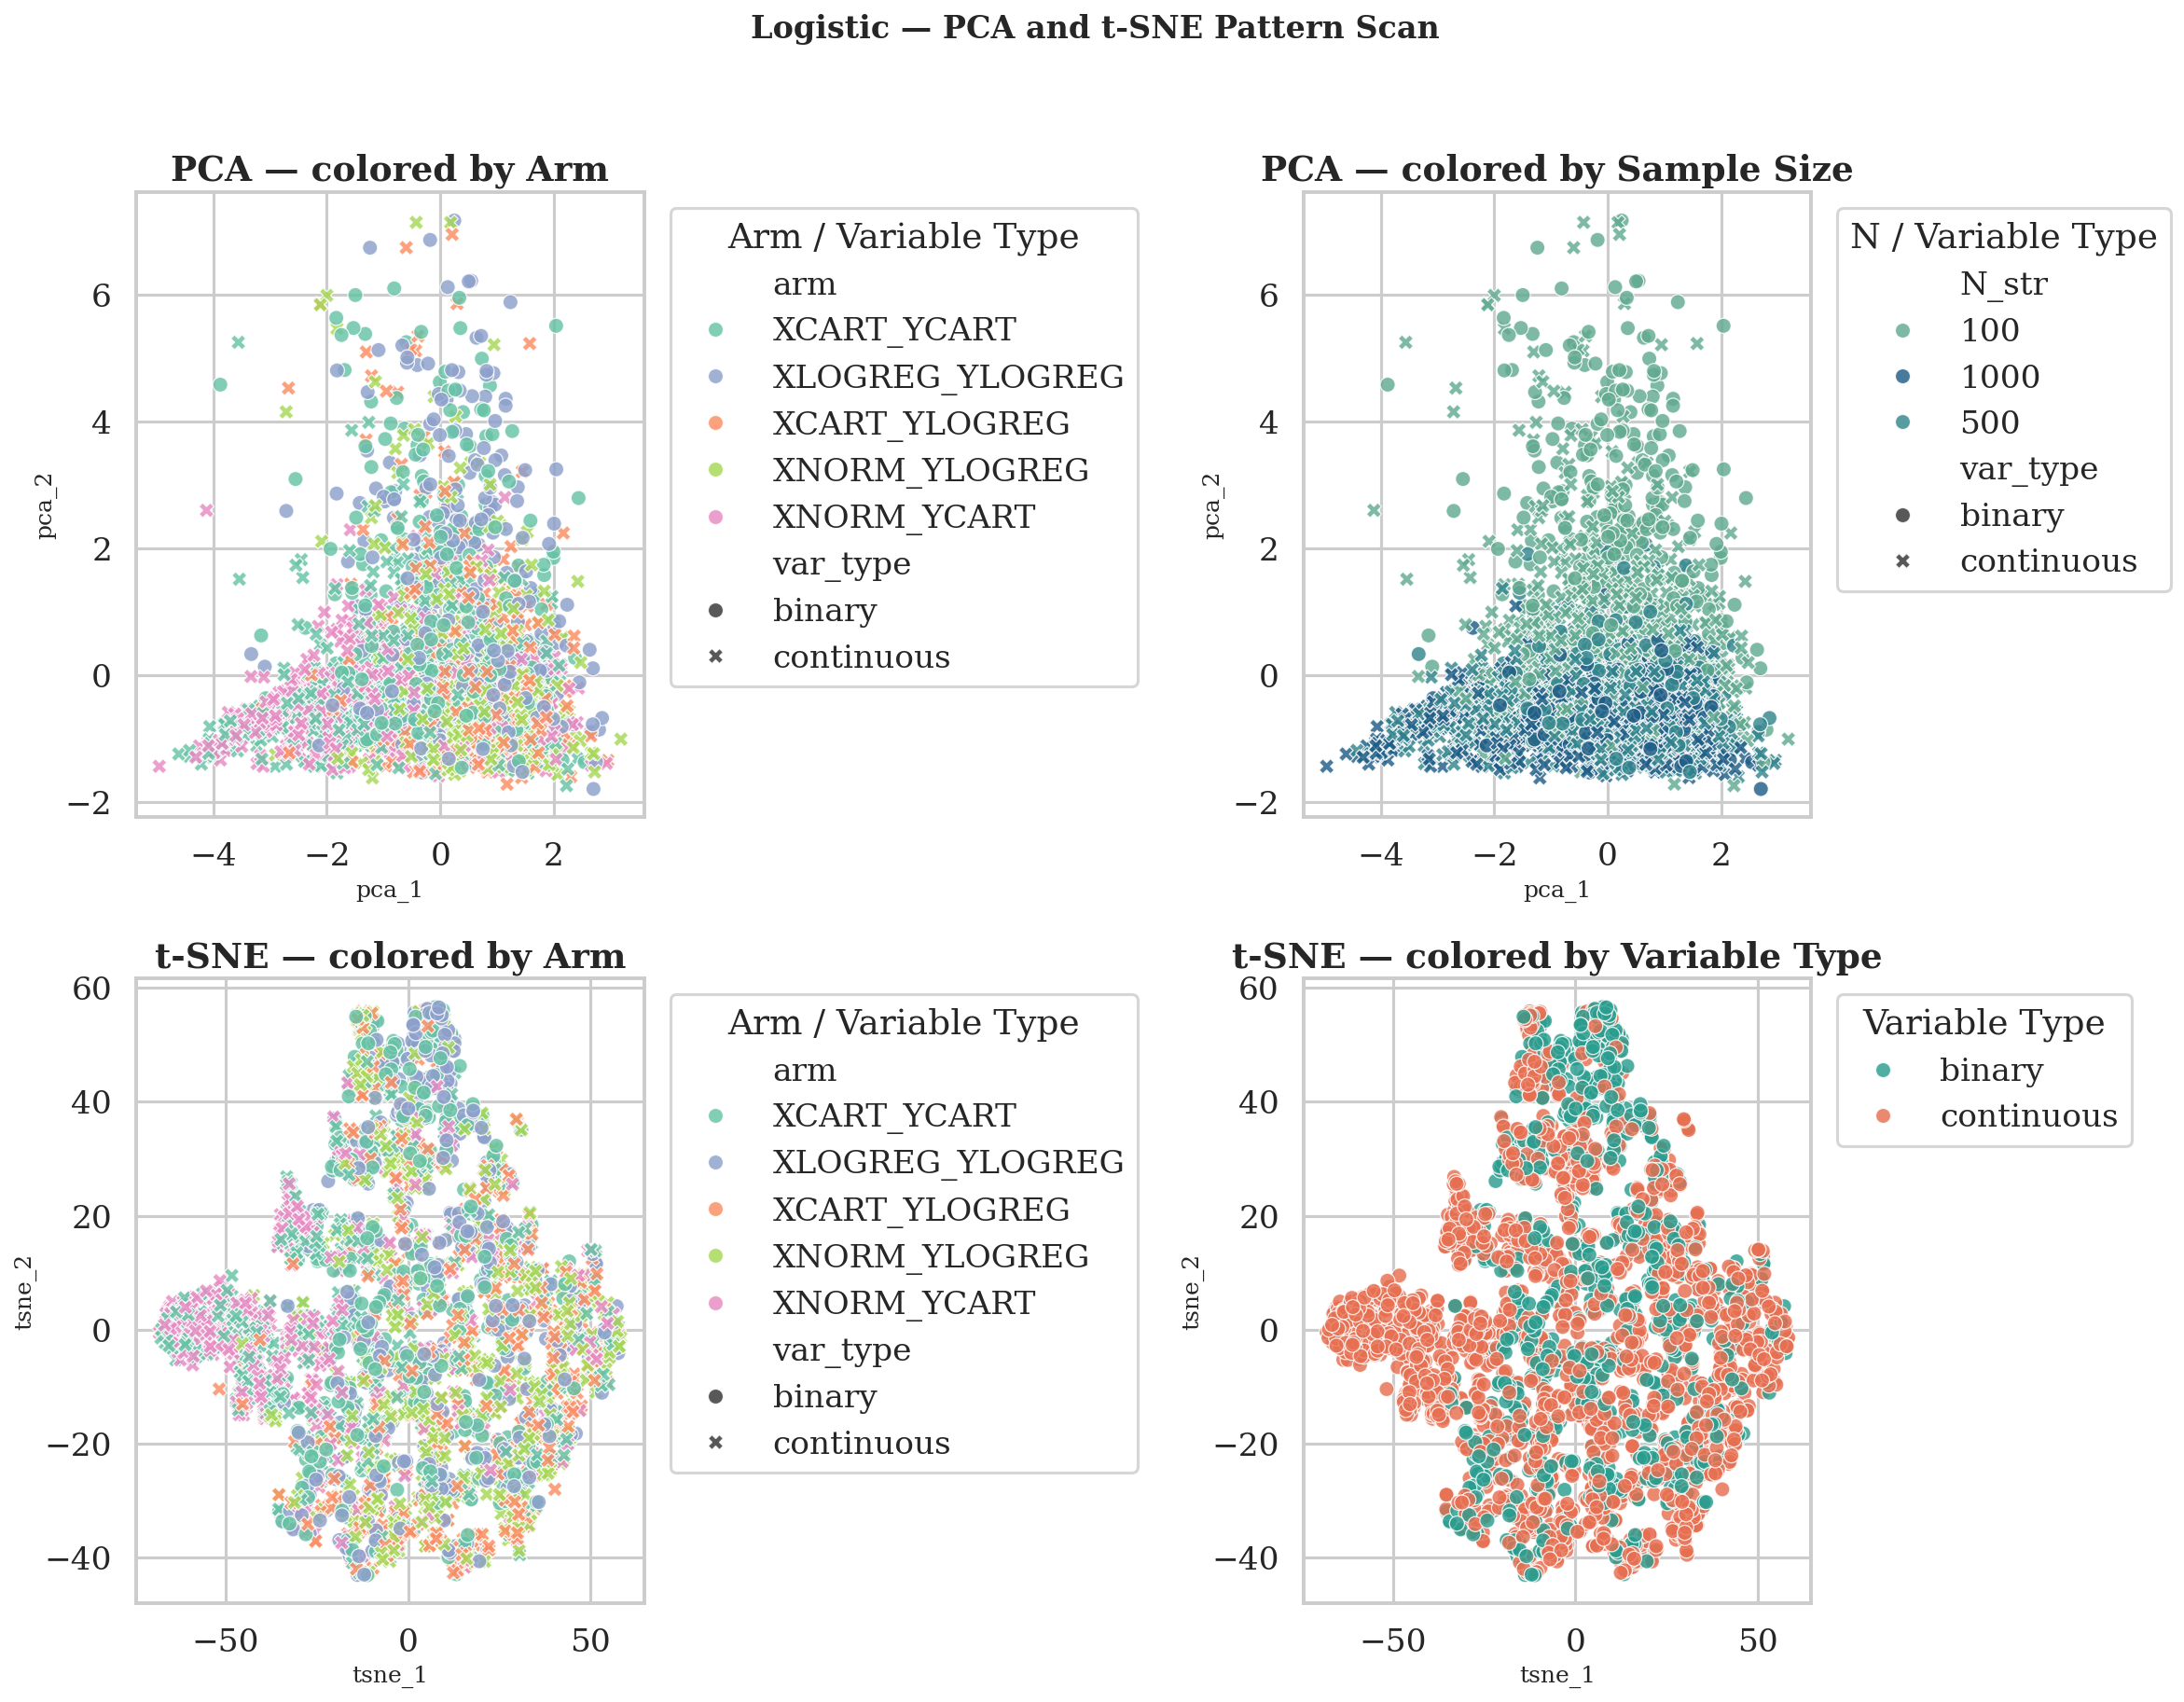

Saved -> ../results/logistic_report_figures/logistic_pattern_scan_pca_tsne.png
Explained variance ratio (PCA): [0.388 0.363]
t-SNE perplexity used: 35


In [5]:
# ── PCA + t-SNE ───────────────────────────────────────────────────────────────
EMBED_FEATURES = [
    "ci_overlap_pct",
    "log10_bias_ratio",
    "log10_ci_width_ratio",
    "mean_abs_bias_od",
    "mean_abs_bias_sd",
]

embed_df = df[["arm", "var_type", "N", "p", "rho", "sigma_2"] + EMBED_FEATURES].dropna().copy()
embed_df = embed_df.sample(n=min(len(embed_df), 3000), random_state=42).reset_index(drop=True)

if len(embed_df) < 10:
    print("Not enough complete rows for PCA/t-SNE after dropping NaNs.")
else:
    X_embed = embed_df[EMBED_FEATURES].copy()
    for col in EMBED_FEATURES:
        lo, hi = X_embed[col].quantile([0.005, 0.995])
        X_embed[col] = X_embed[col].clip(lo, hi)

    X = StandardScaler().fit_transform(X_embed)
    pca = PCA(n_components=2, random_state=42)
    pca_xy = pca.fit_transform(X)

    perplexity = min(35, max(8, len(embed_df) // 20))
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        random_state=42,
    )
    tsne_xy = tsne.fit_transform(X)

    embed_df["pca_1"] = pca_xy[:, 0]
    embed_df["pca_2"] = pca_xy[:, 1]
    embed_df["tsne_1"] = tsne_xy[:, 0]
    embed_df["tsne_2"] = tsne_xy[:, 1]

    n_palette = dict(zip([str(v) for v in N_VALS], sns.color_palette("crest", len(N_VALS))))

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    sns.scatterplot(
        data=embed_df, x="pca_1", y="pca_2",
        hue="arm", palette=ARM_PALETTE, style="var_type",
        alpha=0.82, s=60, ax=axes[0, 0]
    )
    axes[0, 0].set_title("PCA — colored by Arm")
    axes[0, 0].legend(title="Arm / Variable Type", bbox_to_anchor=(1.02, 1), loc="upper left")

    sns.scatterplot(
        data=embed_df.assign(N_str=embed_df["N"].astype(str)), x="pca_1", y="pca_2",
        hue="N_str", palette=n_palette, style="var_type",
        alpha=0.82, s=60, ax=axes[0, 1]
    )
    axes[0, 1].set_title("PCA — colored by Sample Size")
    axes[0, 1].legend(title="N / Variable Type", bbox_to_anchor=(1.02, 1), loc="upper left")

    sns.scatterplot(
        data=embed_df, x="tsne_1", y="tsne_2",
        hue="arm", palette=ARM_PALETTE, style="var_type",
        alpha=0.82, s=60, ax=axes[1, 0]
    )
    axes[1, 0].set_title("t-SNE — colored by Arm")
    axes[1, 0].legend(title="Arm / Variable Type", bbox_to_anchor=(1.02, 1), loc="upper left")

    sns.scatterplot(
        data=embed_df, x="tsne_1", y="tsne_2",
        hue="var_type", palette=VAR_TYPE_PALETTE,
        alpha=0.82, s=60, ax=axes[1, 1]
    )
    axes[1, 1].set_title("t-SNE — colored by Variable Type")
    axes[1, 1].legend(title="Variable Type", bbox_to_anchor=(1.02, 1), loc="upper left")

    fig.suptitle(
        f"{TARGET_LABEL} — PCA and t-SNE Pattern Scan",
        fontsize=16,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    out = os.path.join(fig_dir, f"{TARGET_REG}_pattern_scan_pca_tsne.png")
    fig.savefig(out)
    plt.show()
    print(f"Saved -> {out}")
    print("Explained variance ratio (PCA):", np.round(pca.explained_variance_ratio_, 3))
    print(f"t-SNE perplexity used: {perplexity}")

## Univariate Descriptive Analysis

Each figure isolates one factor at a time while mixing the remaining dimensions, matching the requested main-text simplification.

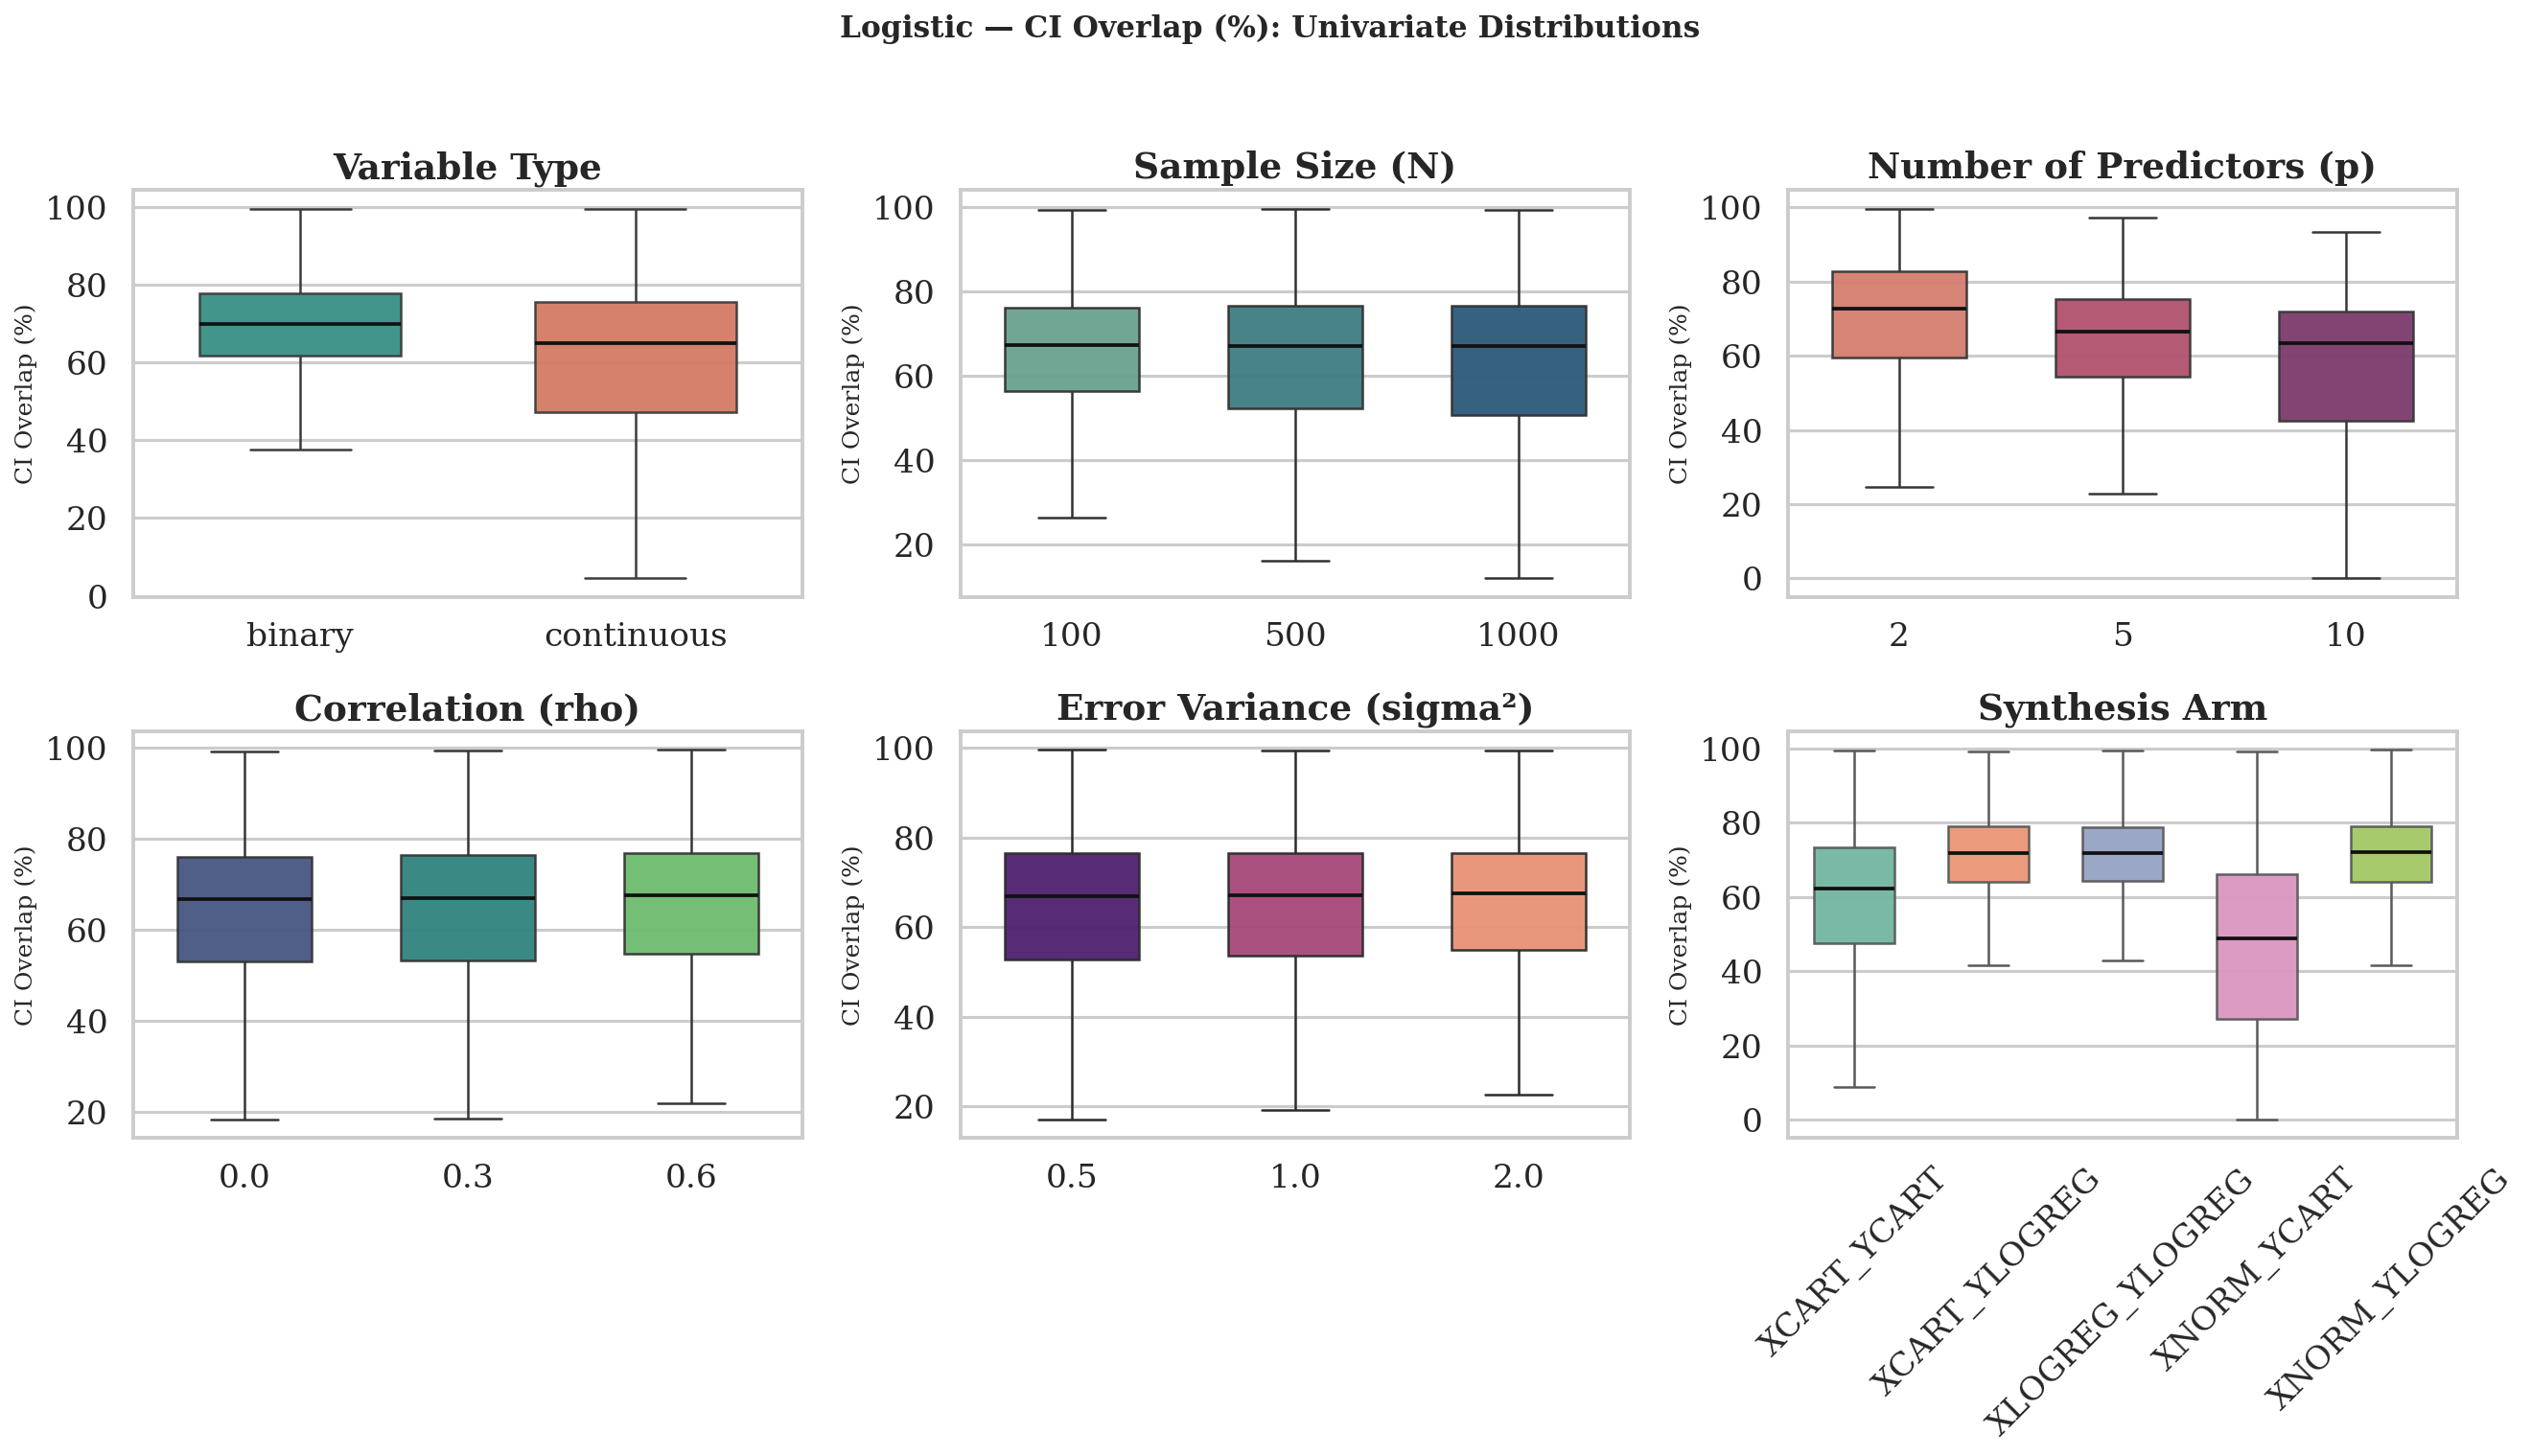

Saved -> ../results/logistic_report_figures/logistic_cio_univariate.png


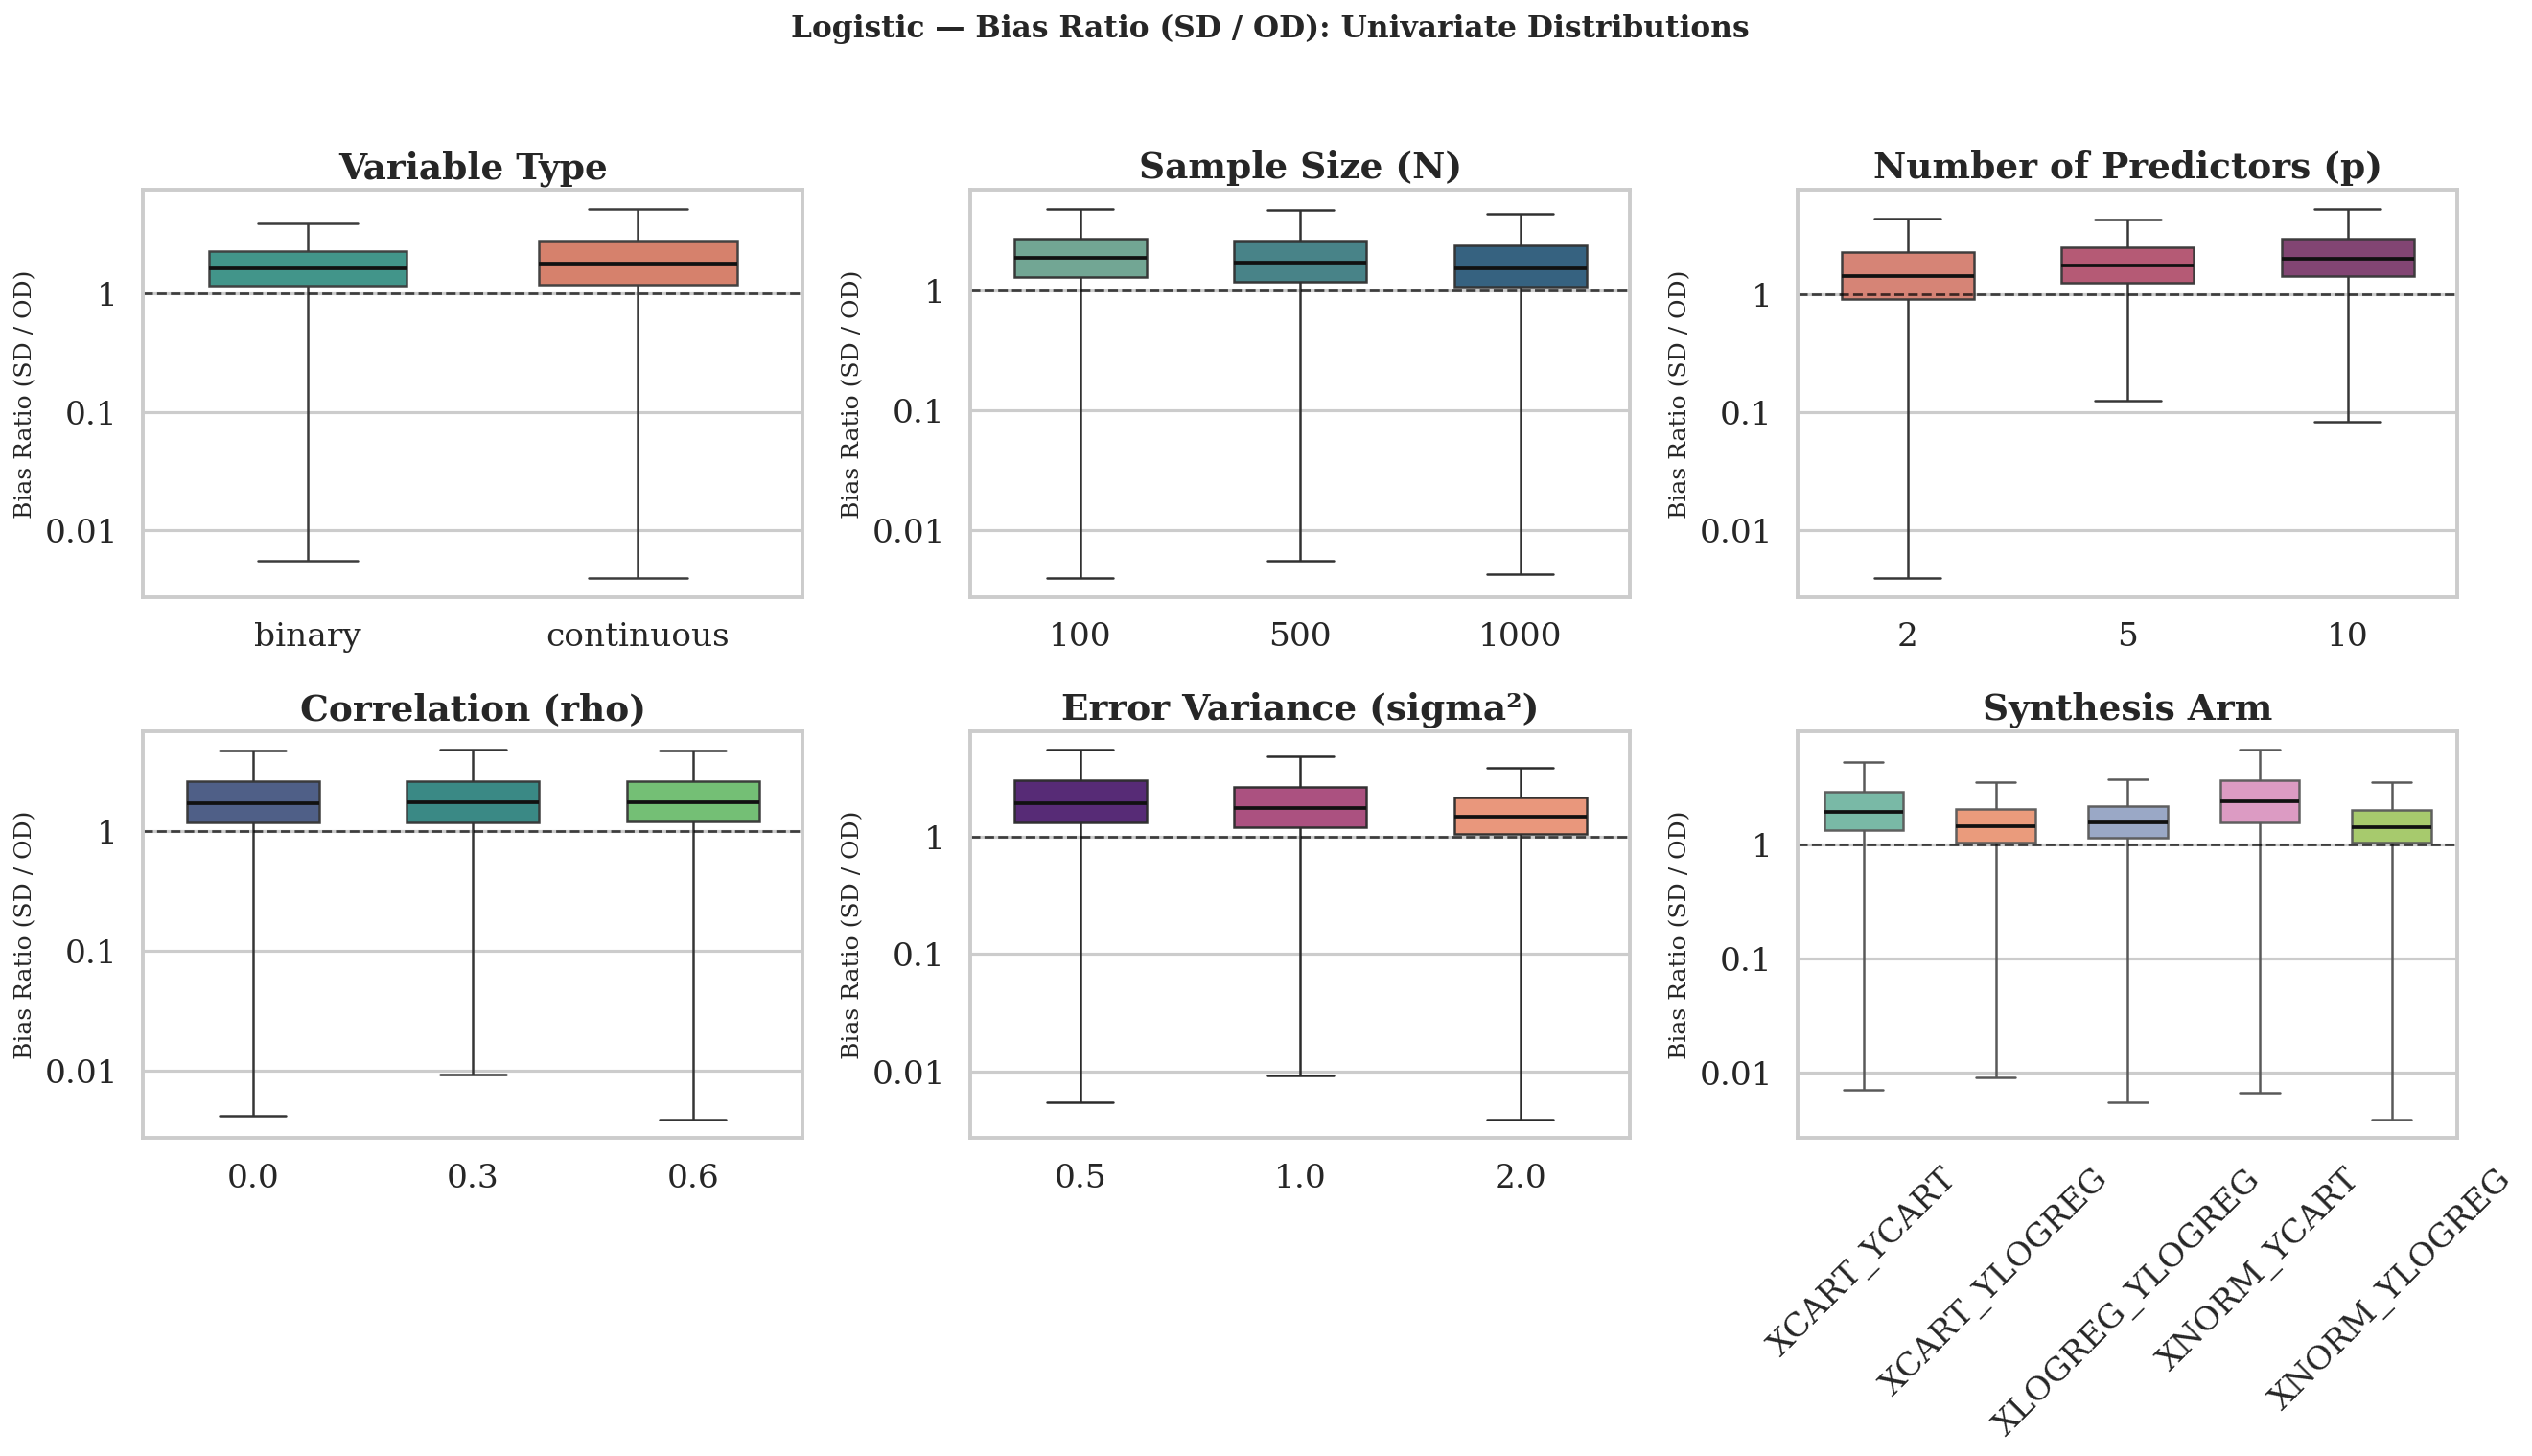

Saved -> ../results/logistic_report_figures/logistic_bias_ratio_univariate.png


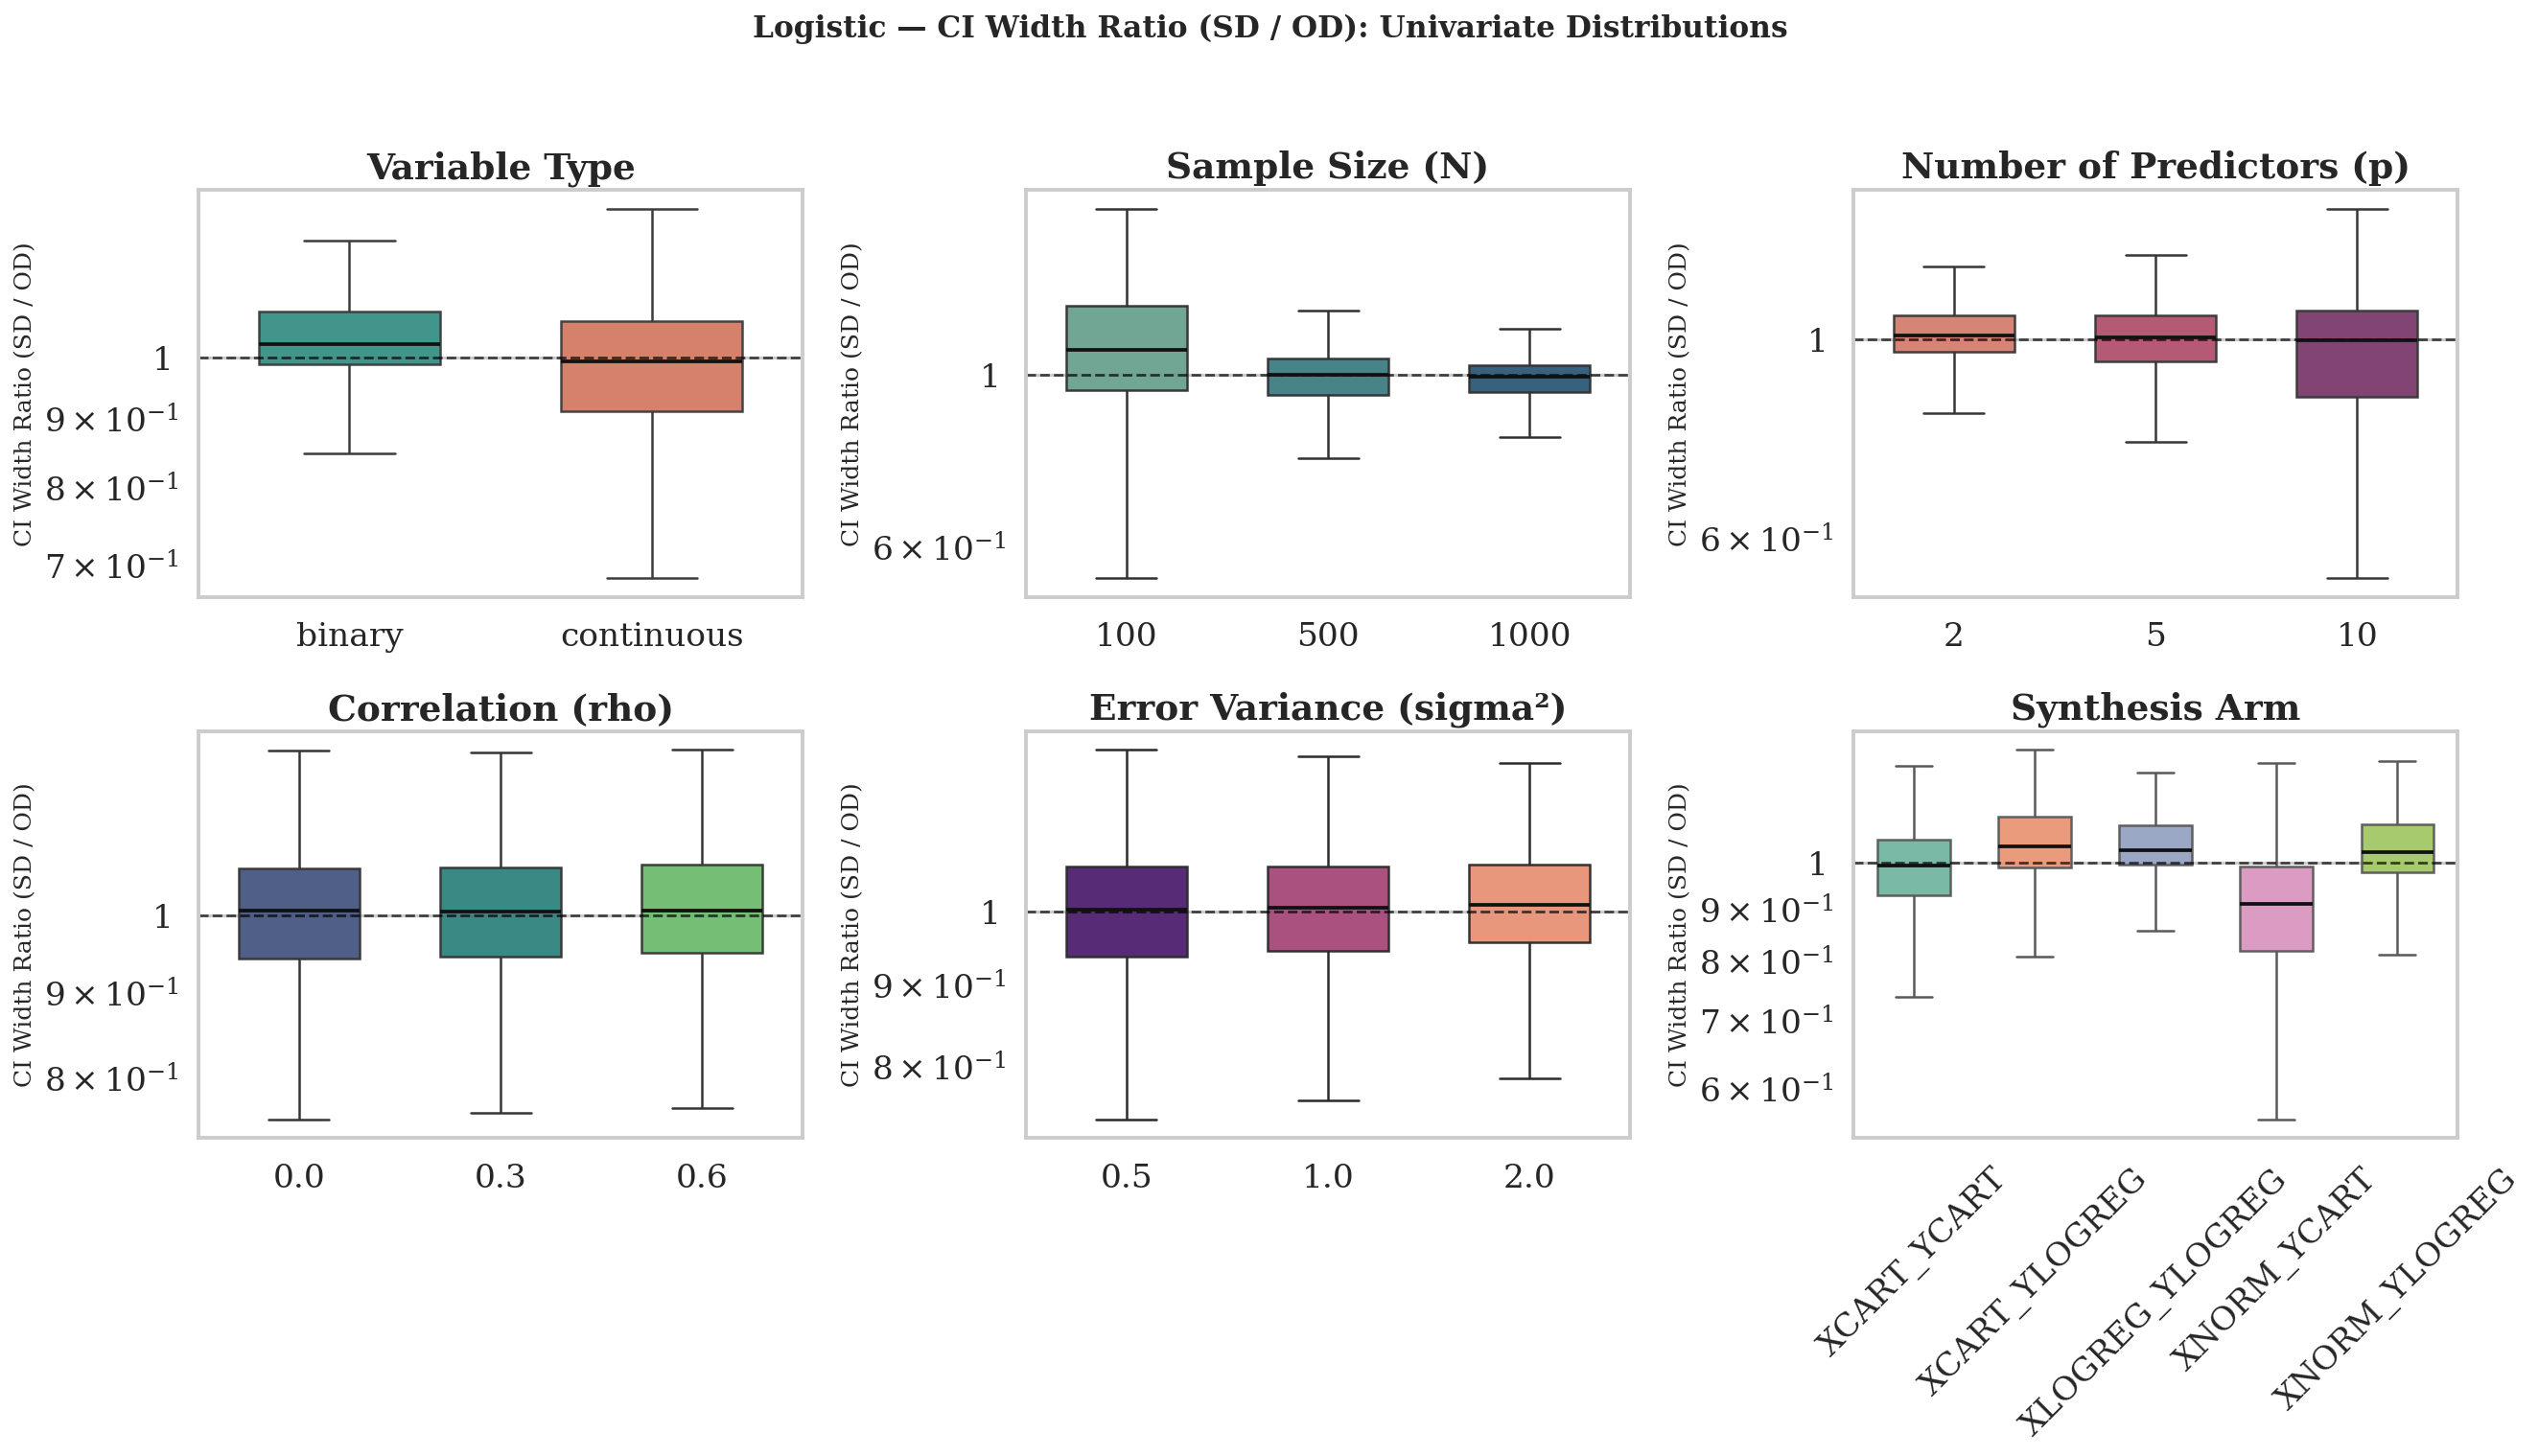

Saved -> ../results/logistic_report_figures/logistic_ci_width_ratio_univariate.png


In [6]:
for metric_col, metric_label, file_stub in METRICS:
    make_univariate_distribution_grid(df, metric_col, metric_label, file_stub)

## Cross-Analysis by Method

The combined synthesis arm is crossed one-to-one with the remaining factors to emphasize where method choice changes the distribution of the selected indicators.

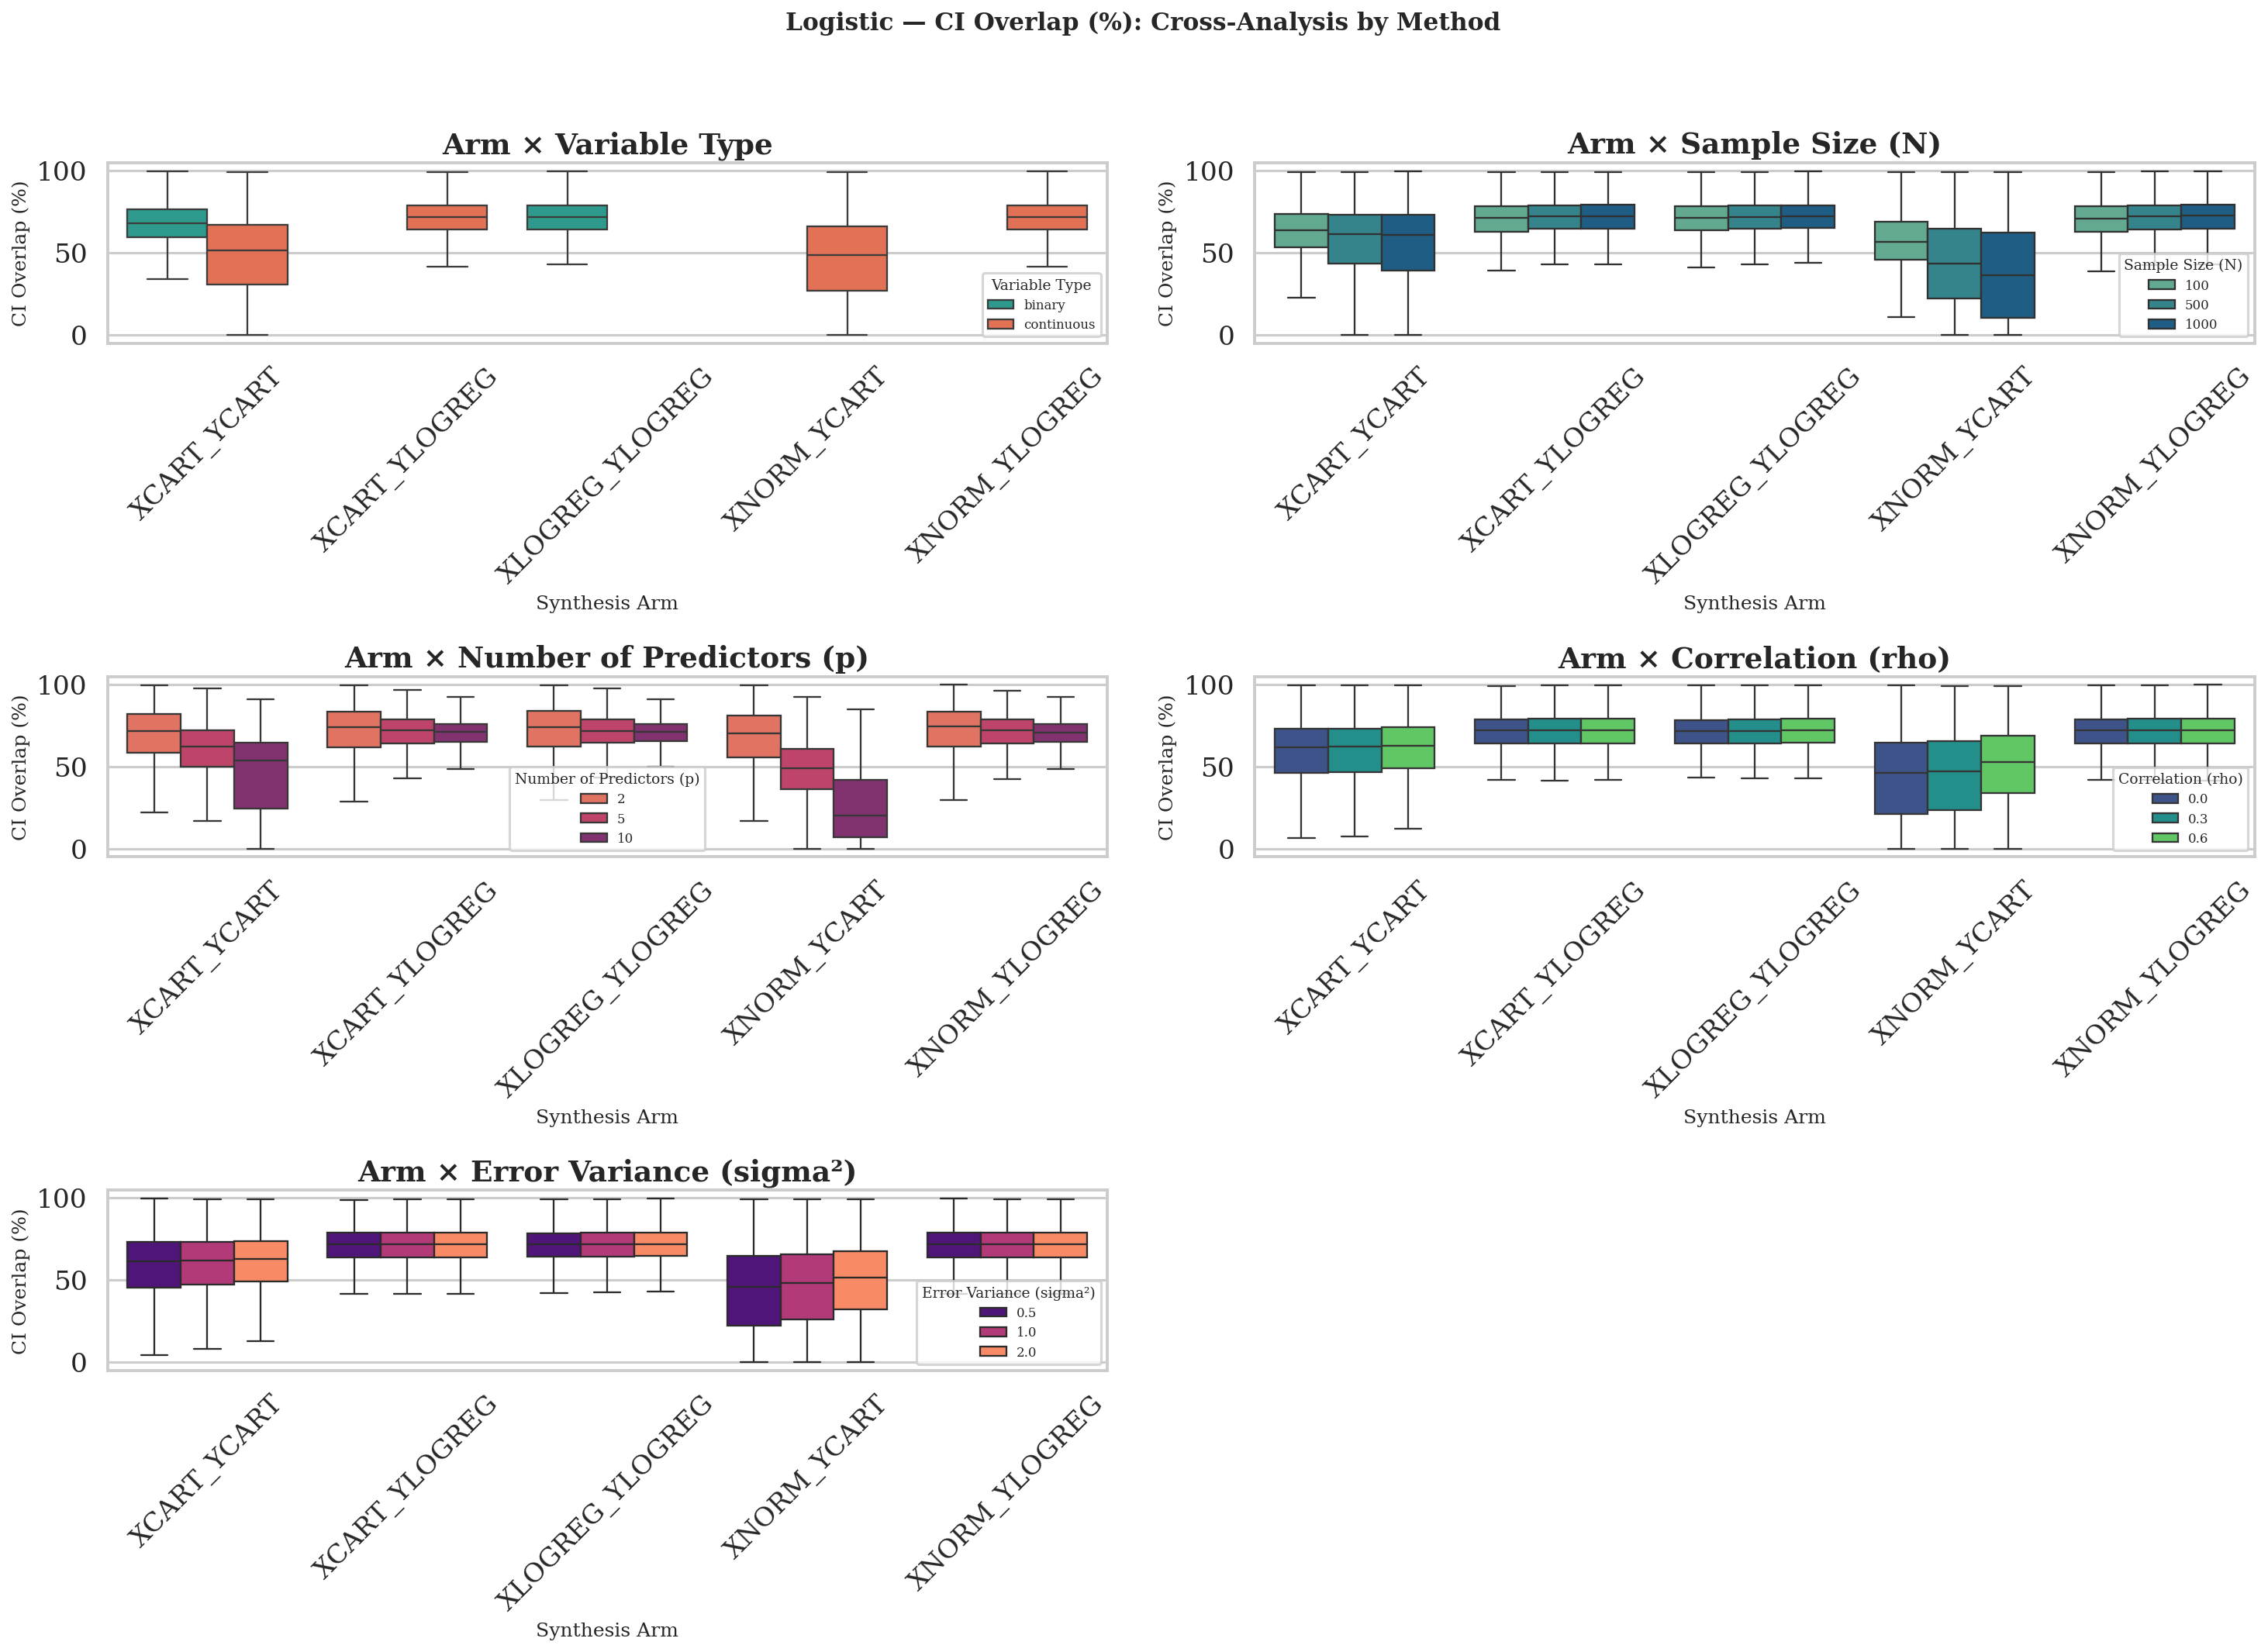

Saved -> ../results/logistic_report_figures/logistic_cio_by_method.png


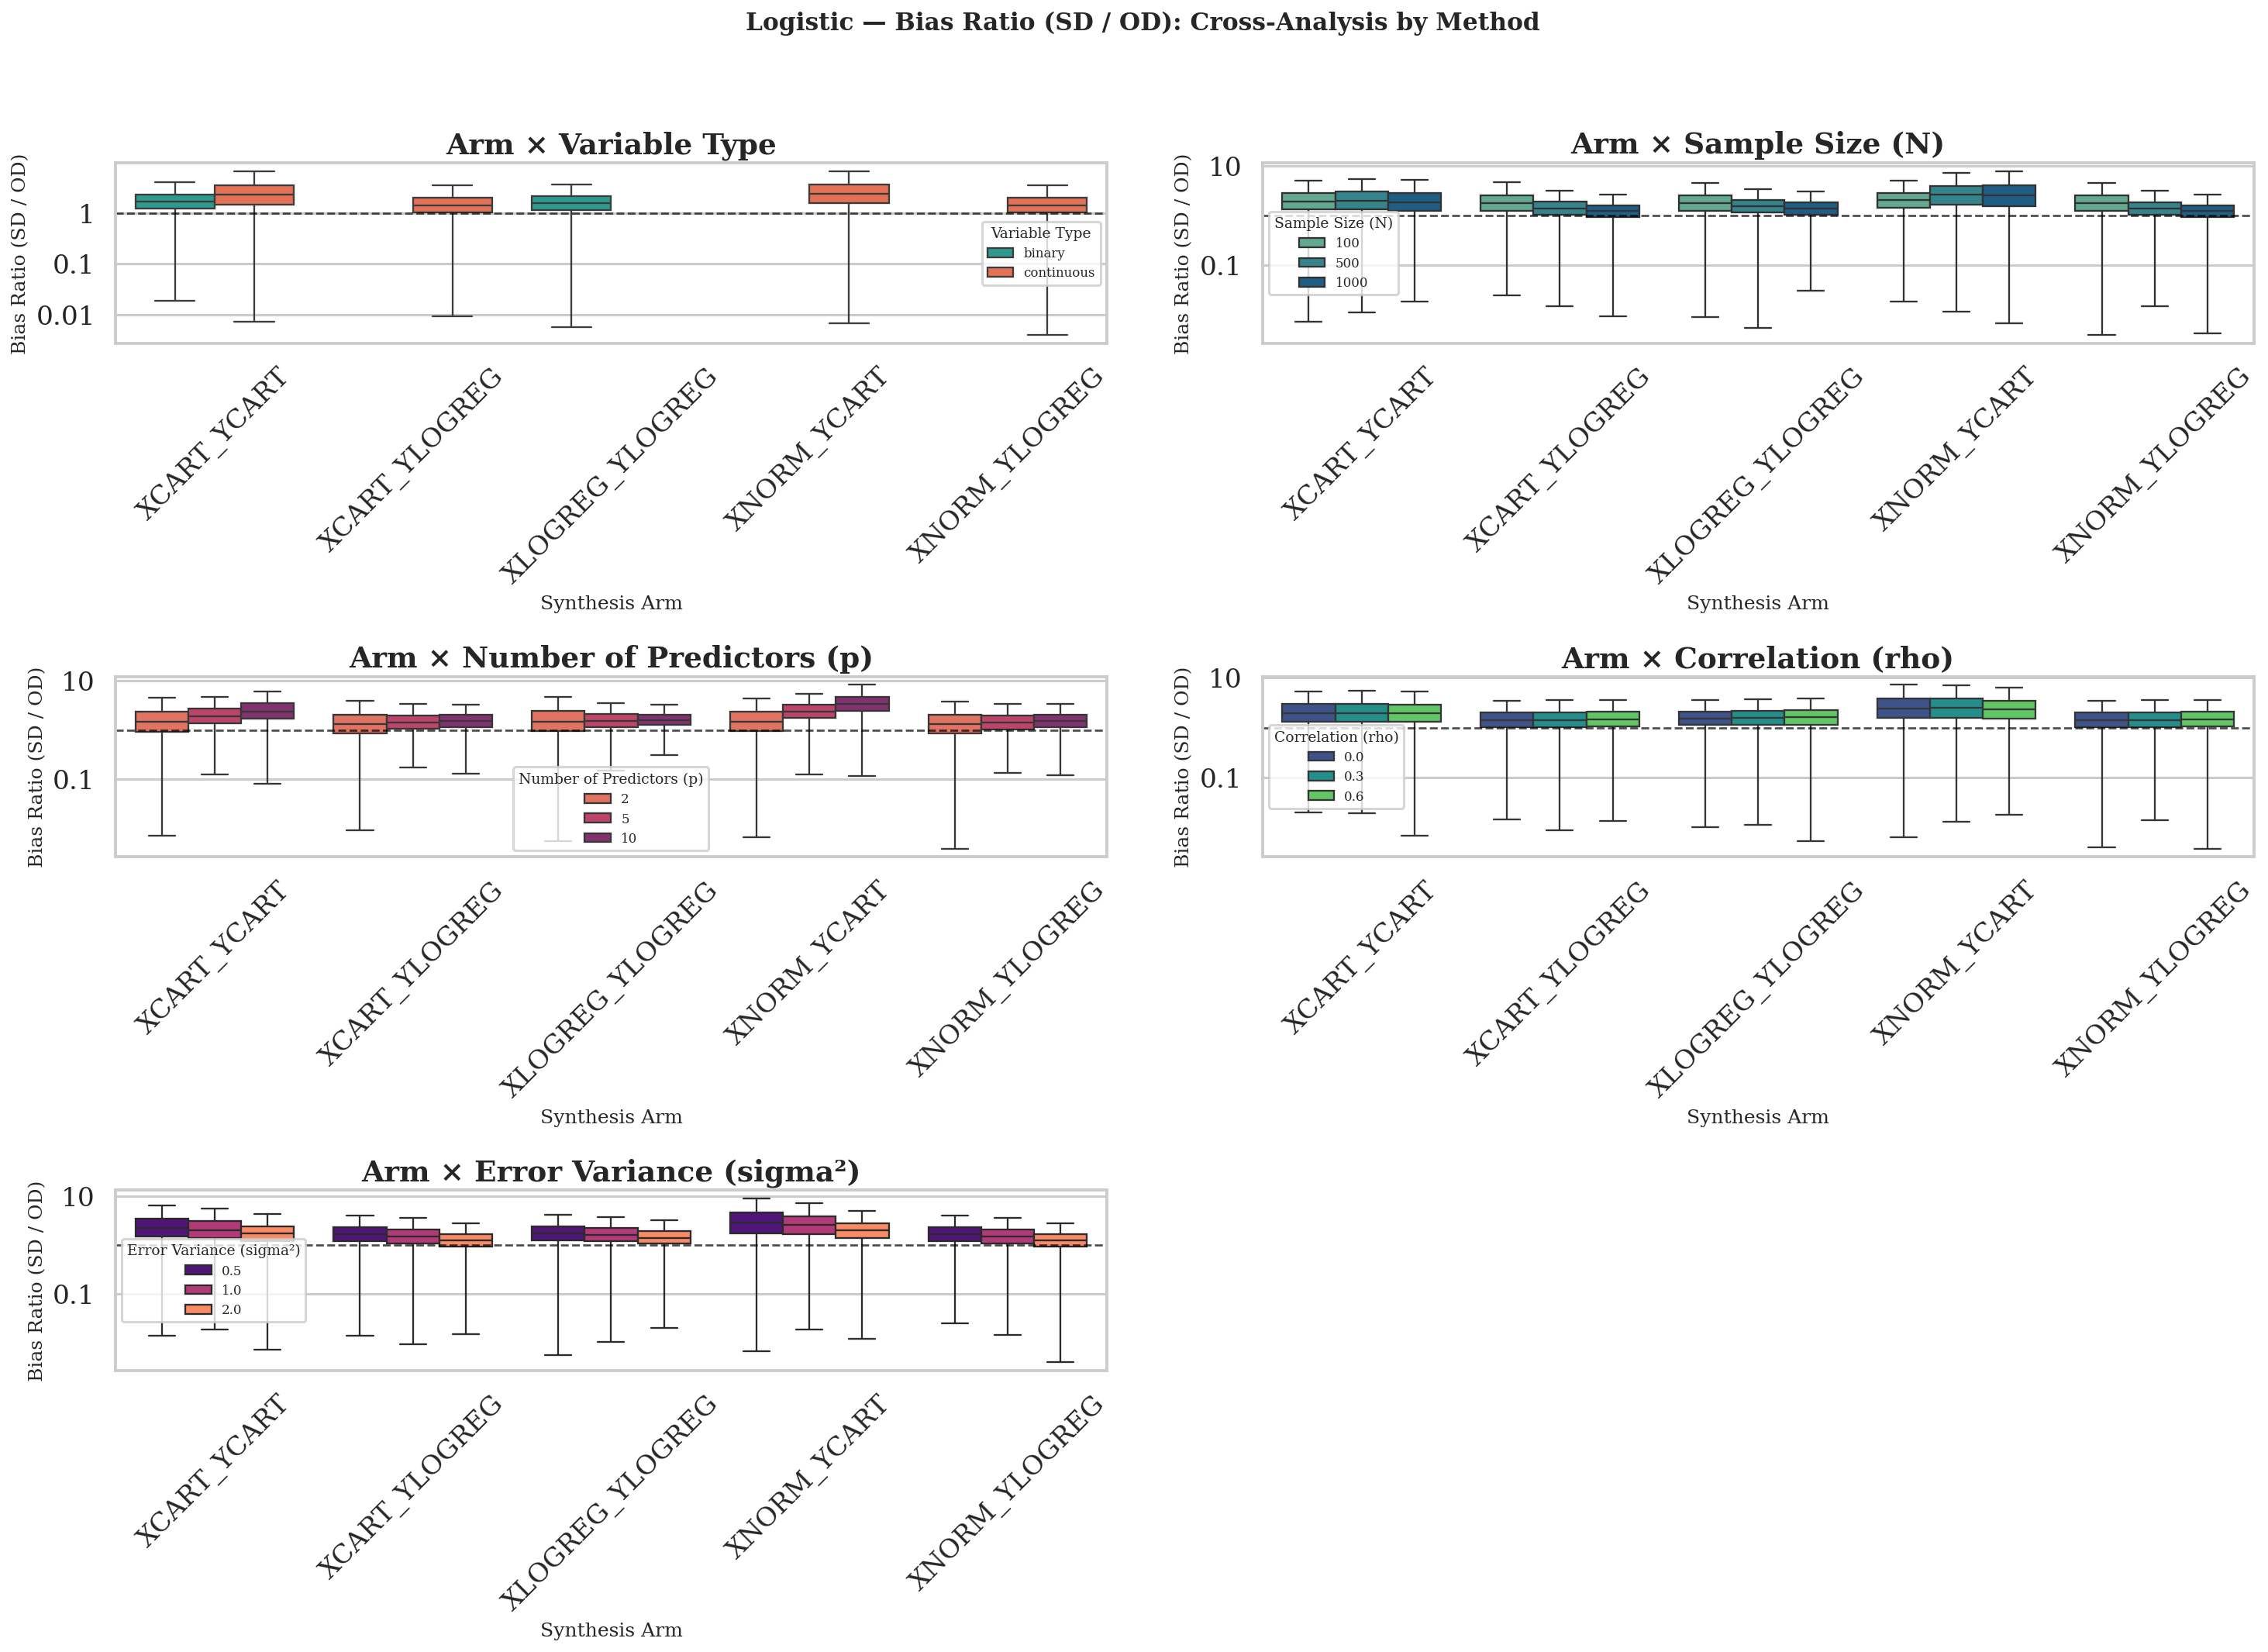

Saved -> ../results/logistic_report_figures/logistic_bias_ratio_by_method.png


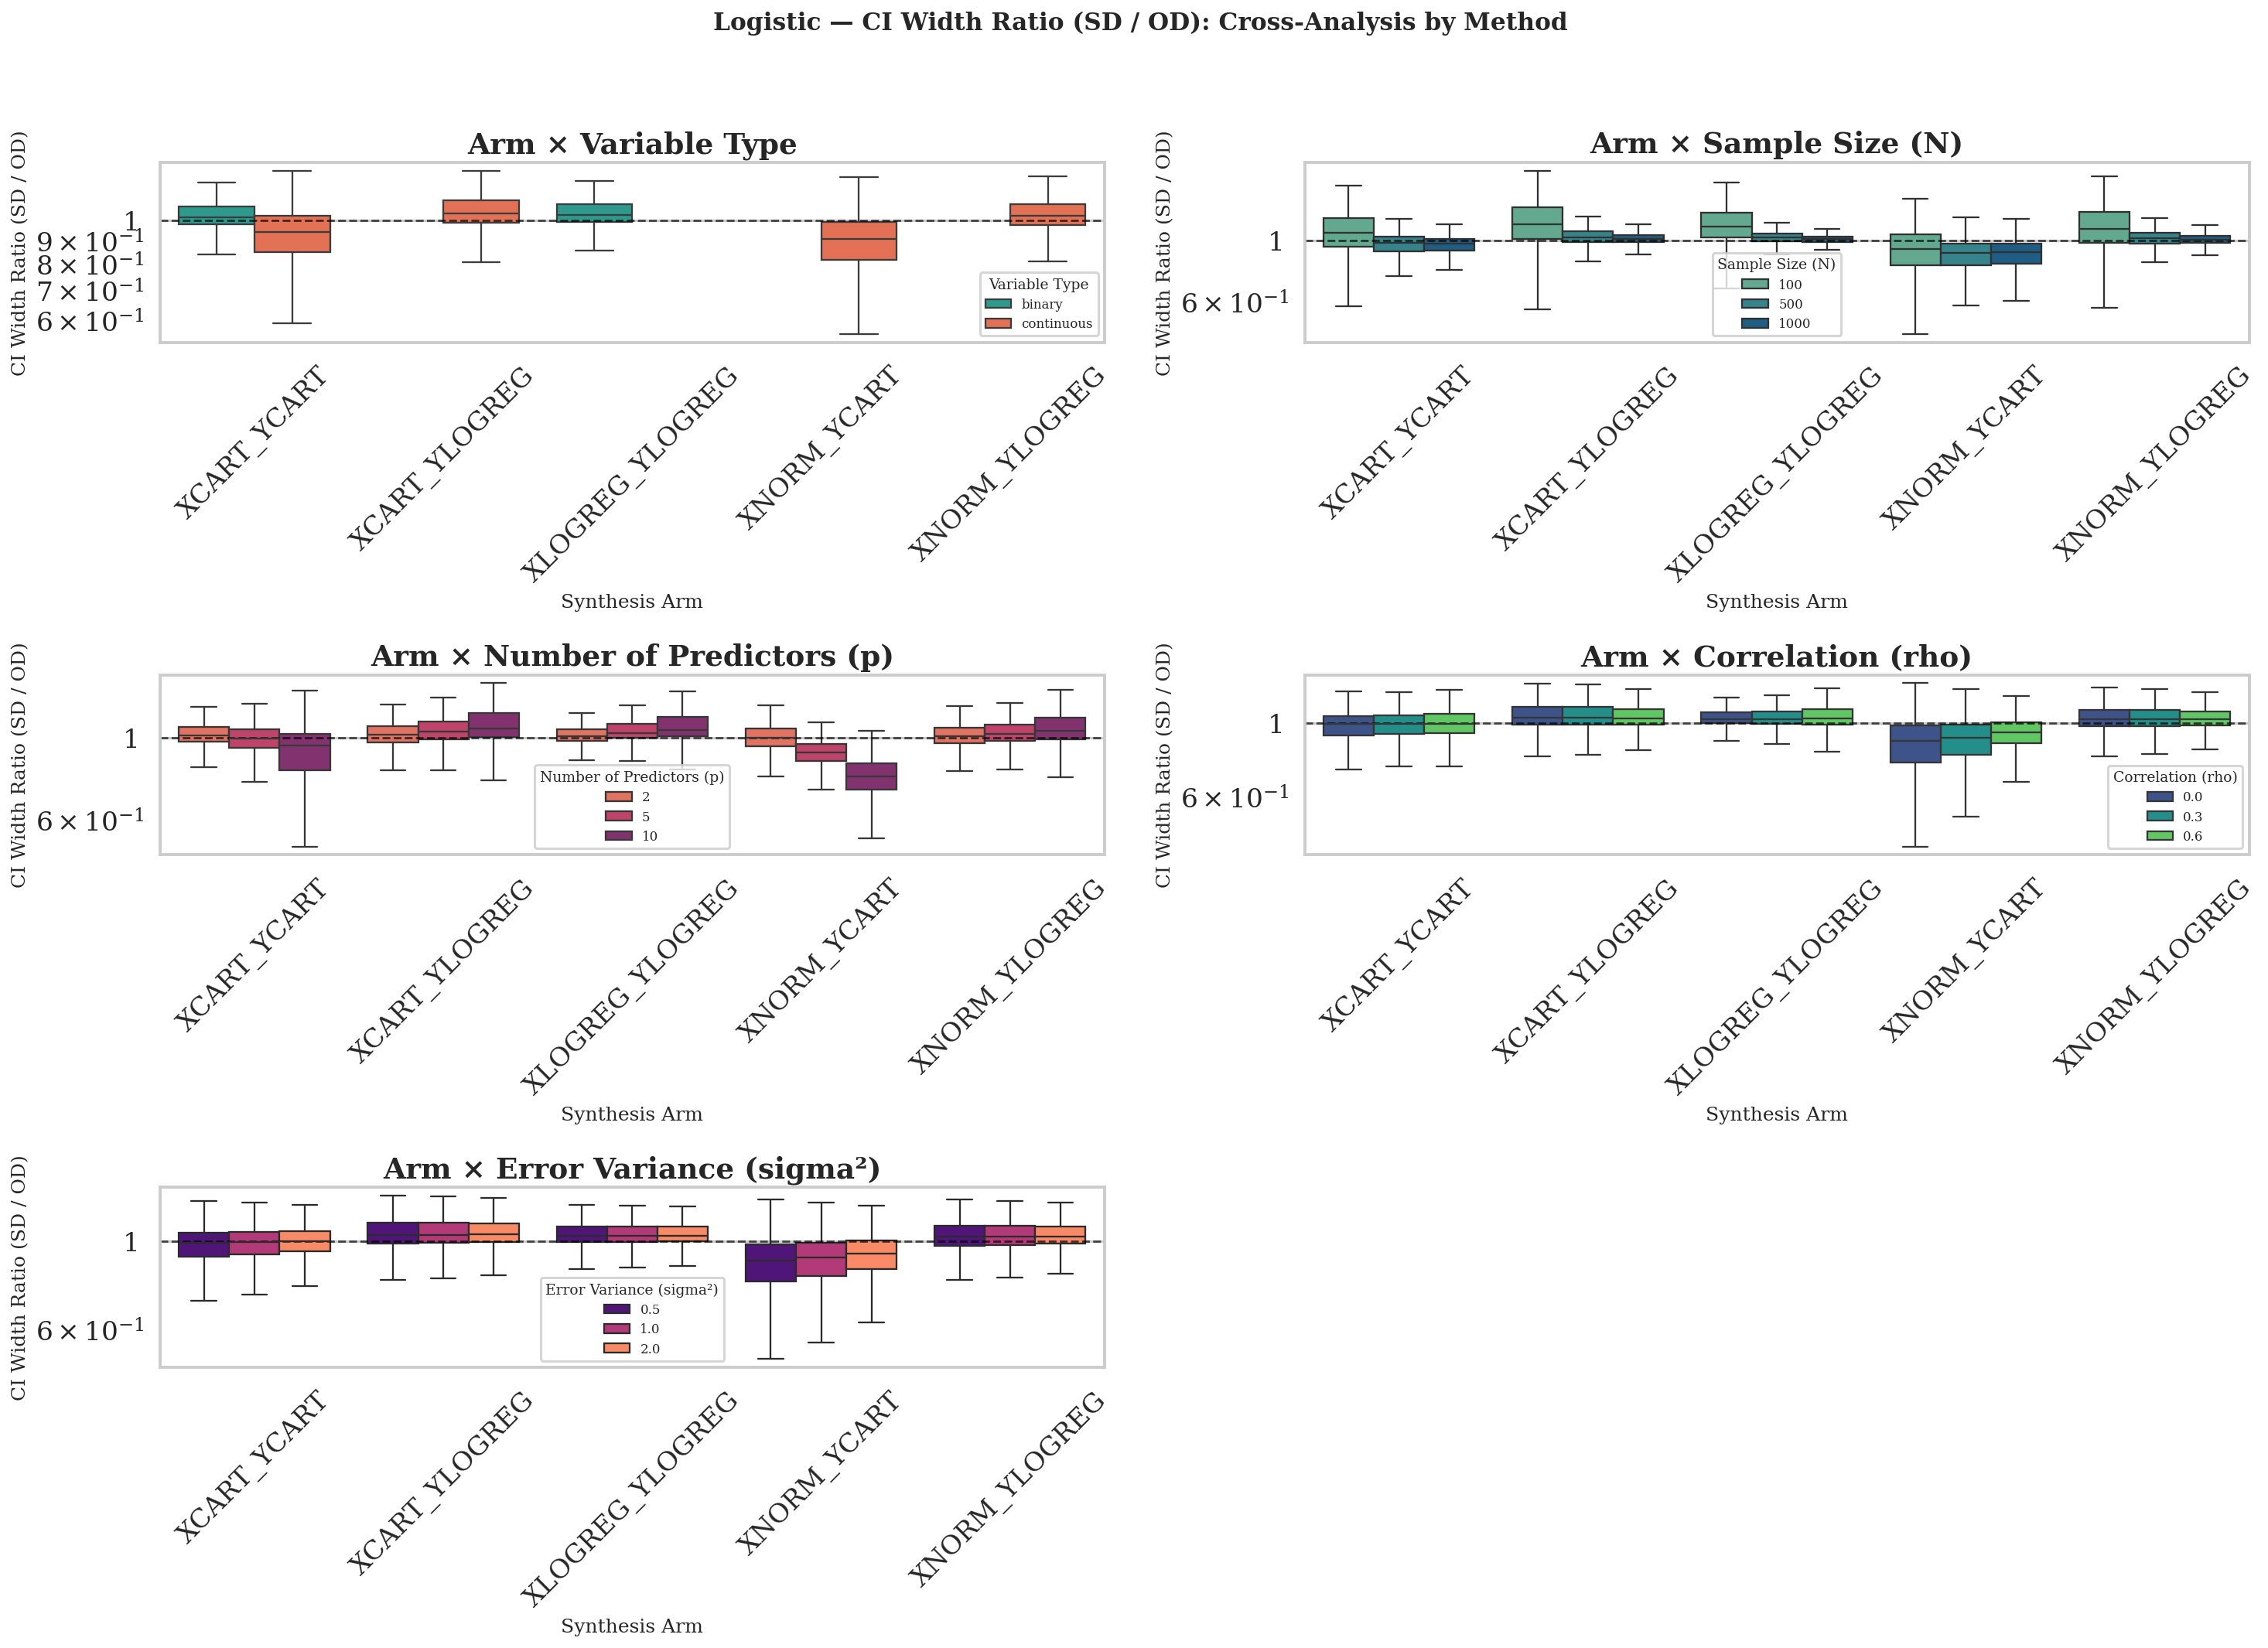

Saved -> ../results/logistic_report_figures/logistic_ci_width_ratio_by_method.png


In [7]:
for metric_col, metric_label, file_stub in METRICS:
    make_method_cross_grid(df, metric_col, metric_label, file_stub)

## Compact Summary

Median and interquartile range for the three main indicators, grouped by variable type and synthesis arm.

In [8]:
summary = (
    df.groupby(["var_type", "arm"])[["ci_overlap_pct", "bias_ratio", "ci_width_ratio"]]
      .agg(["median", lambda s: s.quantile(0.25), lambda s: s.quantile(0.75)])
      .round(3)
)
summary.columns = [
    "cio_median", "cio_q25", "cio_q75",
    "bias_ratio_median", "bias_ratio_q25", "bias_ratio_q75",
    "width_ratio_median", "width_ratio_q25", "width_ratio_q75",
]
display(summary.style
    .format({
        "cio_median": "{:.2f}", "cio_q25": "{:.2f}", "cio_q75": "{:.2f}",
        "bias_ratio_median": "{:.3f}", "bias_ratio_q25": "{:.3f}", "bias_ratio_q75": "{:.3f}",
        "width_ratio_median": "{:.3f}", "width_ratio_q25": "{:.3f}", "width_ratio_q75": "{:.3f}",
    })
    .background_gradient(subset=["cio_median", "cio_q25", "cio_q75"], cmap="YlGn")
    .background_gradient(subset=["bias_ratio_median", "bias_ratio_q25", "bias_ratio_q75"], cmap="YlOrRd_r")
    .background_gradient(subset=["width_ratio_median", "width_ratio_q25", "width_ratio_q75"], cmap="PuBuGn_r")
    .set_caption(f"{TARGET_LABEL} — Compact Summary (median and IQR)")
)
summary

cio_median  cio_q25  cio_q75  bias_ratio_median  \
var_type   arm                                                                
binary     XCART_YCART          67.838   59.437   76.310              1.708   
           XLOGREG_YLOGREG      71.842   64.359   78.712              1.556   
continuous XCART_YCART          51.488   30.922   67.070              2.304   
           XCART_YLOGREG        71.892   64.009   78.911              1.427   
           XNORM_YCART          48.814   27.013   66.123              2.380   
           XNORM_YLOGREG        71.946   64.015   78.939              1.423   

                            bias_ratio_q25  bias_ratio_q75  \
var_type   arm                                               
binary     XCART_YCART               1.216           2.361   
           XLOGREG_YLOGREG           1.139           2.155   
continuous XCART_YCART               1.484           3.517   
           XCART_YLOGREG             1.033           2.023   
           XNORM_YCART               1.548           3.620   
           XNORM_YLOGREG             1.030           2.012   

                            width_ratio_median  width_ratio_q25  \
var_type   arm                                                    
binary     XCART_YCART                   1.016            0.981   
           XLOGREG_YLOGREG               1.029            0.995   
continuous XCART_YCART                   0.944            0.852   
           XCART_YLOGREG                 1.036            0.989   
           XNORM_YCART                   0.911            0.819   
           XNORM_YLOGREG                 1.024            0.978   

                            width_ratio_q75  
var_type   arm                               
binary     XCART_YCART                1.074  
           XLOGREG_YLOGREG            1.087  
continuous XCART_YCART                1.026  
           XCART_YLOGREG              1.109  
           XNORM_YCART                0.991  
           XNORM_YLOGREG              1.089